## OBJECTIVE

Fit several models with different polynomial degrees, and analyze the errors of the models by comparing their bias, variance, and MSE, in order to identify which ones represent underfitting, appropriate fitting, and overfitting.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn import datasets
from sklearn import preprocessing
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import validation_curve
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

import matplotlib.pyplot as plt

Linear R2 Score: 0.15422825991280154
Polynomial R2 Score: 0.17382701905834974


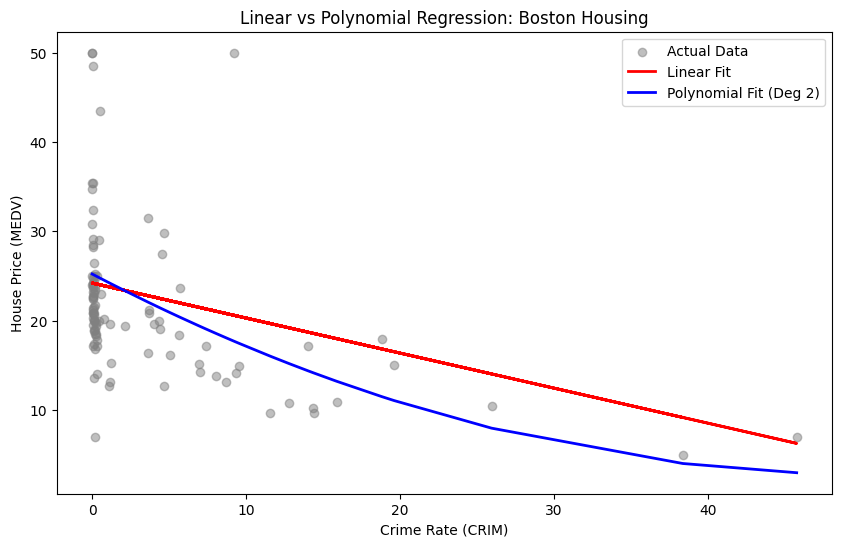

In [13]:
# Load the boston housing dataset
boston = pd.read_csv("HousingData.csv")
df = boston

# We use only one feature (CRIM: crime rate)
df['CRIM'].fillna(df['CRIM'].mean(), inplace=True)
X = df[["CRIM"]] 
Y = df["MEDV"]

#Split the data into training and testing (e.g. 80% / 20% and others)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Linear Regression 
model_lin = LinearRegression().fit(X_train, Y_train)


Y_pred_lin = model_lin.predict(X_test)

# R_2 score evaluation
r2_lin = r2_score(Y_test, Y_pred_lin)
print(f"Linear R2 Score: {r2_lin}")


#POLYNOMIAL REGRESSION (2nd degree)

# We transform the data to include squared features (X^2)
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train) #Fit: La máquina poly mira los datos para ver cómo son. 
# Transform: Changes the format (añade la columna de unos y ajusta el formato). 
X_test_poly = poly.transform(X_test) #We just transform the x_test so we can use it.


# We train a new linear model using the transformed polynomial features
model_poly = LinearRegression().fit(X_train_poly, Y_train)

Y_pred_poly = model_poly.predict(X_test_poly)

#R_SCORE EVALUTATION
r2_poly = r2_score(Y_test, Y_pred_poly)
print(f"Polynomial R2 Score: {r2_poly}")


#Visualization 
plt.figure(figsize=(10, 6))


plt.scatter(X_test, Y_test, color='gray', alpha=0.5, label='Actual Data')

# Plot the Linear Regression Line
plt.plot(X_test, Y_pred_lin, color='red', linewidth=2, label='Linear Fit')

# Plot the Polynomial Regression Line
# (We sort the values so the line looks smooth on the graph)
sorted_zip = sorted(zip(X_test.values, Y_pred_poly))
X_test_sorted, Y_poly_sorted = zip(*sorted_zip)
plt.plot(X_test_sorted, Y_poly_sorted, color='blue', linewidth=2, label='Polynomial Fit (Deg 2)')

plt.xlabel("Crime Rate (CRIM)")
plt.ylabel("House Price (MEDV)")
plt.title("Linear vs Polynomial Regression: Boston Housing")
plt.legend()
plt.show()



## DIFFERENT POLYNOMIAL DEGREES FIT

In this section we will make an structure such that we can test several degrees at the same type. I used AI in this section to help me make the loop and visualization.

Linear R2 Score: 0.15422825991280154
--- Degree 2 ---
Training MSE: 69.3941
Testing MSE:  60.5864
Difference:   8.8077

--- Degree 3 ---
Training MSE: 68.6666
Testing MSE:  60.8121
Difference:   7.8545

--- Degree 4 ---
Training MSE: 68.5836
Testing MSE:  60.9856
Difference:   7.5981

--- Degree 5 ---
Training MSE: 68.4531
Testing MSE:  61.4954
Difference:   6.9577

--- Degree 6 ---
Training MSE: 68.4174
Testing MSE:  61.6854
Difference:   6.7320

--- Degree 10 ---
Training MSE: 80.6723
Testing MSE:  67.5600
Difference:   13.1123

--- Degree 15 ---
Training MSE: 84.8656
Testing MSE:  73.6006
Difference:   11.2650

--- Degree 20 ---
Training MSE: 84.9987
Testing MSE:  74.5943
Difference:   10.4044



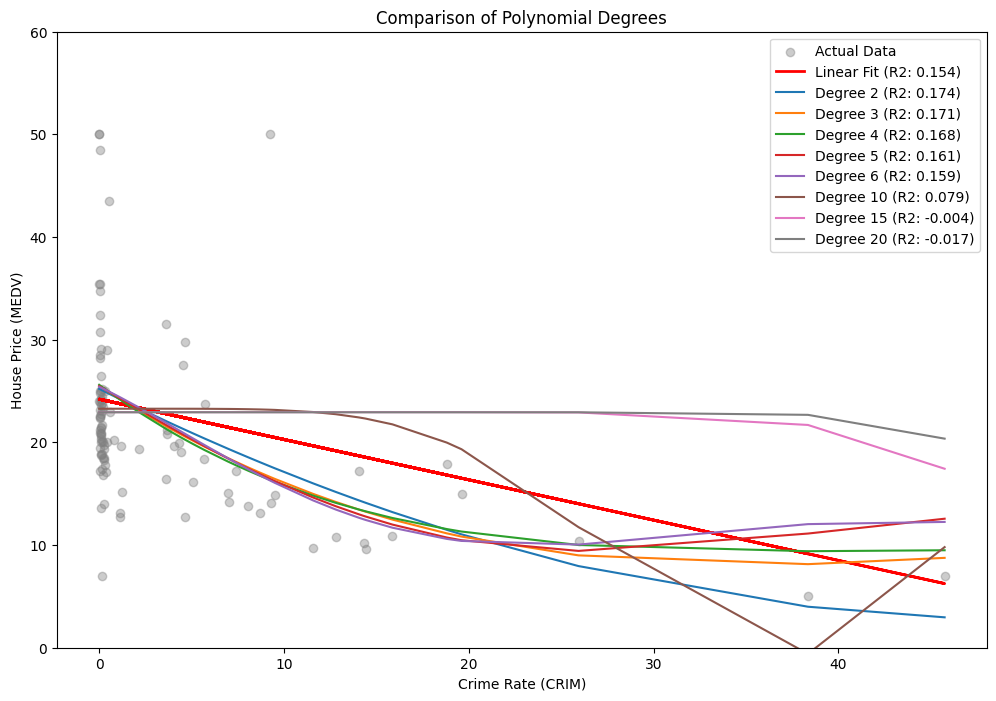

In [22]:
#Split the data into training and testing (e.g. 80% / 20% and others)
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# Linear Regression 
model_lin = LinearRegression().fit(X_train, Y_train)


Y_pred_lin = model_lin.predict(X_test)

# R_2 score evaluation
r2_lin = r2_score(Y_test, Y_pred_lin)
print(f"Linear R2 Score: {r2_lin}")


#POLYNOMIAL REGRESSION (2nd degree)

#The degrees we selected
degrees = [2, 3, 4, 5, 6, 10, 15, 20] 


plt.figure(figsize=(12, 8))
plt.scatter(X_test, Y_test, color='gray', alpha=0.4, label='Actual Data')
plt.plot(X_test, Y_pred_lin, color='red', linewidth=2, label=f"Linear Fit (R2: {r2_lin:.3f})")



for d in degrees:
    
    # Create polynomial features
    poly = PolynomialFeatures(degree=d)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)
    
    # Fit the linear model using those features
    model = LinearRegression().fit(X_train_poly, Y_train)
    
    # Get the R2 score directly from the model
    score = model.score(X_test_poly, Y_test)
    
    # We predict using the test set
    Y_train_pred = model.predict(X_train_poly)
    Y_test_pred = model.predict(X_test_poly)


    #MSE CALCULATION 
    mse_train = mean_squared_error(Y_train, Y_train_pred)
    mse_test = mean_squared_error(Y_test, Y_test_pred)
    
    # We sort the X values just so the line draws smoothly from left to right
    # Otherwise, the line will look like a scribble.
    X_test_flat = X_test.values.flatten()
    sort_idx = X_test_flat.argsort()

    plt.plot(X_test_flat[sort_idx], Y_test_pred[sort_idx], label=f"Degree {d} (R2: {score:.3f})")

    #PRINTING OF THE MSE FOR EACH DEGREE
    print(f"--- Degree {d} ---")
    print(f"Training MSE: {mse_train:.4f}")
    print(f"Testing MSE:  {mse_test:.4f}")
    print(f"Difference:   {abs(mse_train - mse_test):.4f}\n")

    
"""
Why we use argsort: Our dataset is ordered by whatever happened when the data was collected (House 1, House 2, House 3).
House 1 might have a Crime Rate of 0.5, and House 2 might have 0.1.
If you tell the computer: "Draw a line from (0.5, price) to (0.1, price)", the line goes backwards.
sort_idx = X_test_flat.argsort() creates a list of "directions" (e.g., "the smallest value is at index 5, the next is at index 2..."). 
By applying those directions to our plot, the line moves strictly from left to right, which is the only way to see the "shape" of the polynomial.
"""



# PLOTTING OF THE OLS AND DEGREES
plt.xlabel("Crime Rate (CRIM)")
plt.ylabel("House Price (MEDV)")
plt.title("Comparison of Polynomial Degrees")
plt.legend()
plt.ylim(0, 60) # Keeping the Y axis stable to see the curves clearly
plt.show()




## Bias and Variance analysis

Observing the graph we can see our different polynomial regression models try to fit differently the data. Depending on how they curve or bend we can extract a lot of information about their Bias and Variance, but our deductions will mainly come from analyzing the MSE. 

To understand why MSE tells us about Bias and Variance, we have to look at the Bias-Variance Decomposition formula:
    
$$
Total Error (MSE)=Bias^2+Variance+Irreducible Noise
$$

Bias represents the error caused by our assumptions being too simple. If our Training MSE is high (like your Degree 1 $R^2$ of 0.15), it means even when the model is looking at the answers, it cannot find a way to get close to them, because a straight line is "biased" towards being straight, it refuses to bend to follow the data. Our Bias is high across the results. Even at the best degree, an MSE of 60 is quite high, meaning "Crime Rate" alone is not enough to accurately predict house prices.
      

Variance represents the error caused by the model being too sensitive to the specific data points in the training set.
When a model has High Variance, it "memorizes" the training data. This makes the Training MSE very low, but because the memorized noise doesn't exist in the Test Set, the Testing MSE becomes very high. The difference of MSE column is our Variance indicator.

From Degree 2 to Degree 6, your difference is stable/decreasing (8.8 → 6.7). This means the model is relatively stable.
At Degree 10, the difference jumps to 13.11. This spike tells us that the model is starting to bend and lose its ability to generalize.

## Underfitting and Overfitting models

To analyze the fitting of a model we will observe that models with high Bias like the linear fit (Degree = 1) or  degrees like 15 and 20 are far too simple to predict accurately the MEDV regarding CRIME, this underfitting yields low values of $R^2$ and high Train MSE.

While on the other hand we can see overfitting for degrees like 10 which tries to reach every point curving sharply, this is reinforced by the fact that it has the highest variance, a difference of 13.1123 between the training MSE and test MSE.

Finally the best model for this analysis is disputed between degree 2 and 3. For us to dive into a profound analysis of this result, we will enumerate a number of reasons.

In economics and sociology, relationships are rarely straight lines (Degree 1), but they are also rarely "roller coasters" (Degree 10).

For degree 1 a straight line assumes that for every 1% increase in crime, the house price drops by a fixed amount (e.g., -$5,000). This is unrealistic. Real-world "negative" factors like crime usually follow a curve of diminishing returns. Going from 0% to 5% crime has a massive impact on house prices.Going from 40% to 45% crime has almost no impact, because the neighborhood is already considered "high crime" and the prices have already hit the "floor." Degree 2 and 3  are the simplest mathematical shape that can "bend" to show a sharp drop followed by a flattening out (a plateau). 

We can also see that both are the models that neither underfit or overfit the dataset they have just enough "flexibility" to capture the "Signal" (the actual relationship) while being "stiff" enough to ignore the "Noise" (random fluctuations in individual houses).